In [54]:
import sys
import os
# current_dir = os.path.dirname(os.path.abspath(__file__))
# # 루트 디렉토리
# root_dir = os.path.abspath(os.path.join(current_dir, '..'))
# # 루트 디렉토리를 sys.path에 추가
# sys.path.append(root_dir)
from utils.MY_GNN import MGAtest
from utils.build_dataset import inference_build_dataset 

import torch
import pandas as pd
import dgl

import base64
from rdkit import Chem
from rdkit.Chem import rdDepictor, MolSurf
from rdkit.Chem.Draw import rdMolDraw2D, MolToFile, _moltoimg
import matplotlib.cm as cm
import matplotlib

select_task_list = [
    'pgp_substrate','pgp_inhibitor','ob','f20','hia', # Absorption
    'bbb_logbb', # Distribution
    't0.5','oct2', # Excretion
    'oatp1b3','oatp1b1','cyp3a4_inhibitor','cyp2d6_inhibitor','cyp2c9_inhibitor','cyp2c19_inhibitor','cyp1a2_inhibitor',
    'cyp3a4_substrate','cyp2d6_substrate','cyp2c9_substrate','cyp2c19_substrate','cyp1a2_substrate','bcrp', # Metabolism
    'nr_ahr','nr_ar','nr_ar_lbd','nr_er','nr_er_lbd','nr_tr','nr_gr','nr_ppar_gamma','nr_aromatase','sr_are','sr_atad5','sr_hse','sr_mmp','sr_p53', # Tox21
    'skin_sens','respiratory_tox','micronucleus_tox','herg','h_ht','eye_irritation','eye_corrosion','dili','crustacean','carcinogenicity',
    'biodegradation','bee_tox','avian_tox','ames', # Toxicity
    'skin_permeability','mdck','caco2_reg', # Absorption
    'vd', 'ppb', 'fu', 'bbb_cns', # Distribution
    'cl', # Excretion
    'pkb', 'pka','logd','logp', 'logs', 'logvp', 'hydrationE', 'bp', 'mp', # General property
    'rat_acute_reg', 'fdamdd_reg', 'fm_reg', 'rat_chronic', 'bioconcF', 'lc50dm', 'pyriformis_reg' # Toxicity
]


model = MGAtest(in_feats=40,
                rgcn_hidden_feats=64,
                gnn_out_feats=64,
                n_tasks=73,
                rgcn_drop_out=0.2,
                classifier_hidden_feats=64,
                dropout=0.1,
                return_weight=True,
                loop=True)

# model.load_state_dict(torch.load("/home/doyamoon/MGA-main/model/deep_pk_fixed_early_stop.pth"))
# stopper = EarlyStopping(pretrained_model="deep_pk_fixed_early_stop.pth",
#                         patience=50, task_name="",
#                         mode='higher')

model.load_state_dict(torch.load("/home/doyamoon/MGA-main/model/deep_pk_fixed_early_stop.pth", map_location=torch.device('cpu'))['model_state_dict'])
smiles = "CC[C@H](C)[C@H](N)C(=O)O[C@@H]1C[C@@H](n2cc(F)c(=O)[nH]c2=O)O[C@H]1CO"

In [55]:
data_origin = pd.DataFrame({'SMILES': [smiles]})
predict_data = inference_build_dataset(
    dataset_smiles=data_origin, 
    smiles_name='SMILES'
)
predict_data

1/1 molecule is transformed!
[](0) is transformed failed!


/home/doyamoon/miniconda3/envs/ADMET/lib/python3.12/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


[['CC[C@H](C)[C@H](N)C(=O)O[C@@H]1C[C@@H](n2cc(F)c(=O)[nH]c2=O)O[C@H]1CO',
  Graph(num_nodes=25, num_edges=52,
        ndata_schemes={'atom': Scheme(shape=(40,), dtype=torch.int64)}
        edata_schemes={'etype': Scheme(shape=(), dtype=torch.int64), 'normal': Scheme(shape=(), dtype=torch.float32)})]]

In [56]:

def weight_visulize_string(smiles, atom_weight):
    # Move the tensor to CPU and convert to numpy array
    atom_weight = atom_weight.cpu()
    atom_weight_list = atom_weight.squeeze().numpy().tolist()
    max_atom_weight_index = atom_weight_list.index(max(atom_weight_list))
    significant_weight = atom_weight[max_atom_weight_index].item()  # Convert tensor scalar to Python number
    
    mol = Chem.MolFromSmiles(smiles)
    norm = matplotlib.colors.Normalize(vmin=0, vmax=1)
    cmap = cm.get_cmap('Oranges')
    plt_colors = cm.ScalarMappable(norm=norm, cmap=cmap)
    atom_colors = {}
    bond_colors = {}
    # weight_norm = np.array(ind_weight).flatten()
    # threshold = weight_norm[np.argsort(weight_norm)[1]]
    # weight_norm = np.where(weight_norm < threshold, 0, weight_norm)
    atom_new_weight = [0 for x in range(mol.GetNumAtoms())]
    # generate most important significant circle fragment and attach significant weight
    atom = mol.GetAtomWithIdx(max_atom_weight_index)
    # # find neighbors 1
    atom_neighbors_1 = [x.GetIdx() for x in atom.GetNeighbors()]
    # find neighbors 2
    atom_neighbors_2 = []
    for neighbors_1_index in atom_neighbors_1:
        neighbor_1_atom = mol.GetAtomWithIdx(neighbors_1_index)
        atom_neighbors_2 = atom_neighbors_2 + [x.GetIdx() for x in neighbor_1_atom.GetNeighbors()]
    atom_neighbors_2.remove(max_atom_weight_index)
    # find neighbors 3
    atom_neighbors_3 = []
    for neighbors_2_index in atom_neighbors_2:
        neighbor_2_atom = mol.GetAtomWithIdx(neighbors_2_index)
        atom_neighbors_3 = atom_neighbors_3 + [x.GetIdx() for x in neighbor_2_atom.GetNeighbors()]
    atom_neighbors_3 = [x for x in atom_neighbors_3 if x not in atom_neighbors_1]
    # attach neighbor 3 significant weight
    for i in atom_neighbors_3:
        atom_new_weight[i] = significant_weight*0.5
    for i in atom_neighbors_2:
        atom_new_weight[i] = significant_weight
    for i in atom_neighbors_1:
        atom_new_weight[i] = significant_weight
    atom_new_weight[max_atom_weight_index] = significant_weight

    significant_fg_index = [max_atom_weight_index] + atom_neighbors_1 + atom_neighbors_2 + atom_neighbors_3

    for i in range(mol.GetNumAtoms()):
        atom_colors[i] = plt_colors.to_rgba(float(atom_new_weight[i]))

    for i in range(mol.GetNumBonds()):
        bond = mol.GetBondWithIdx(i)
        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()
        x = atom_new_weight[u]
        y = atom_new_weight[v]
        bond_weight = (x+y)/2
        if u in significant_fg_index and v in significant_fg_index:
            bond_colors[i] = plt_colors.to_rgba(float(abs(bond_weight)))
        else:
            bond_colors[i] = plt_colors.to_rgba(float(abs(0)))
    rdDepictor.Compute2DCoords(mol)

    drawer = rdMolDraw2D.MolDraw2DSVG(280, 280)
    drawer.SetFontSize(6)
    op = drawer.drawOptions()

    mol = rdMolDraw2D.PrepareMolForDrawing(mol)
    drawer.DrawMolecule(mol, highlightAtoms=range(0, mol.GetNumAtoms()), highlightBonds=range(0, mol.GetNumBonds()),
                        highlightAtomColors=atom_colors, highlightBondColors=bond_colors)
    drawer.FinishDrawing()

    # Convert SVG to Base64
    svg = drawer.GetDrawingText()
    svg = svg.replace('svg:', '')
    svg_bytes = svg.encode('utf-8')
    base64_svg = base64.b64encode(svg_bytes).decode('utf-8')

    return base64_svg

In [57]:
model.eval()

with torch.no_grad():
    smiles, bg = predict_data[0]
    atom_feats = bg.ndata.pop('atom').float().to('cpu')
    bond_feats = bg.edata.pop('etype').long().to('cpu')
    bg = bg.to('cpu')
    prediction_all, atom_weight_list, node_feats = model(bg, atom_feats, bond_feats, norm=None)
    img_dict = {}  # img_list 대신 img_dict 생성 : for JSON
    for mol_index in range(len(smiles)): 
        atom_smiles = smiles[mol_index]
        img_dict[atom_smiles] = {}  # 각 smiles에 대해 새로운 dict 생성
        for tasks_index, task_name in enumerate(select_task_list):
            bg.ndata['w'] = atom_weight_list[tasks_index]
            bg.ndata['feats'] = node_feats
            unbatch_bg = dgl.unbatch(bg)
            one_atom_weight = unbatch_bg[mol_index].ndata['w']
            one_atom_feats = unbatch_bg[mol_index].ndata['feats']
            img_str = weight_visulize_string(atom_smiles, one_atom_weight)
            img_dict[atom_smiles][task_name] = img_str  # task_name을 키로, img_str을 값으로 저장
    # output[:49] = torch.sigmoid(output[:49])



/tmp/ipykernel_2160855/1192112895.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Oranges')
[13:50:10] 

****
Range Error
idx
Violation occurred on line 209 in file /home/conda/feedstock_root/build_artifacts/rdkit-meta_1722844818947/work/Code/GraphMol/ROMol.cpp
Failed Expression: 5 < 1
----------
Stacktrace:
 0# Invar::Invariant::toString[abi:cxx11]() const in /home/doyamoon/miniconda3/envs/ADMET/lib/python3.12/site-packages/rdkit/../../../libRDKitRDGeneral.so.1
 1# Invar::operator<<(std::ostream&, Invar::Invariant const&) in /home/doyamoon/miniconda3/envs/ADMET/lib/python3.12/site-packages/rdkit/../../../libRDKitRDGeneral.so.1
 2# RDKit::ROMol::getAtomWithIdx(unsigned int) in /home/doyamoon/miniconda3/envs/ADMET/lib/python3.12/site-packages/rdkit/Chem/../../../../libRDKitGraphMol.so.1
 3# 0

RuntimeError: Range Error
	idx
	Violation occurred on line 209 in file Code/GraphMol/ROMol.cpp
	Failed Expression: 5 < 1
	RDKIT: 2024.03.5
	BOOST: 1_84


In [32]:
prediction_all

tensor([[-6.3434e-01, -2.2465e+00,  6.6391e-01,  2.5900e-01,  3.3239e-01,
          5.4655e-01,  4.8248e-02, -1.5795e+00, -2.0458e+00, -1.8063e+00,
         -2.4874e+00, -2.1438e+00, -2.6662e+00, -2.4509e+00, -2.3136e+00,
         -7.3904e-01, -1.0518e+00, -1.6026e-01, -2.7952e-01, -9.8509e-01,
         -2.6488e-01, -3.0602e+00, -1.0462e+00,  9.1104e-01, -6.6278e-03,
         -1.8629e+00, -3.0217e-01, -2.8586e+00, -4.3895e+00, -3.9858e+00,
         -2.1000e+00, -3.3500e+00, -3.5324e+00, -3.5097e+00,  7.2801e-01,
          7.4212e-03, -3.5191e-01,  9.3342e-01, -2.3539e+00,  5.0401e-01,
         -1.8125e+00, -2.9903e+00,  2.1285e-03, -9.4282e-01, -1.2376e+00,
          2.3008e-01, -9.2967e-02, -4.4276e-01,  3.5547e-01, -2.6973e+00,
         -4.5209e+00, -5.5790e+00,  6.8431e-01,  3.1870e+01,  2.5534e-01,
         -3.7138e+00,  4.0264e+00,  8.3118e+00,  3.6974e+00, -7.2473e-01,
         -3.2616e-01, -1.2164e+00, -7.0602e+00, -7.4210e+00,  1.9803e+02,
          1.7704e+02,  1.7701e+00,  1.

In [33]:
len(atom_weight_list)

73

caco2_reg
-5.0715


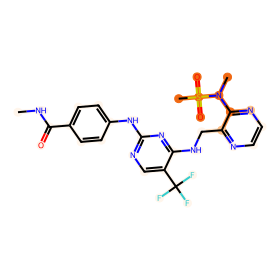

pgp_substrate
0.7378


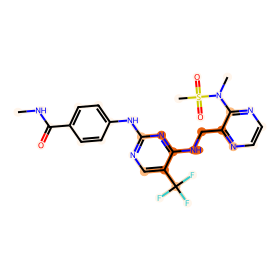

pgp_inhibitor
0.1681


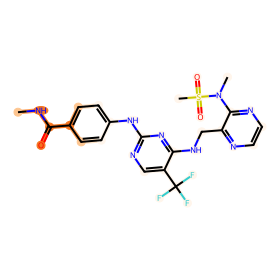

ob
0.8799


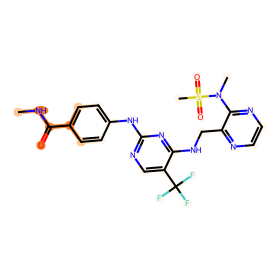

f20
0.8904


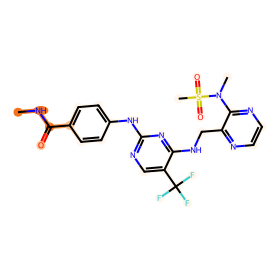

hia
0.9835


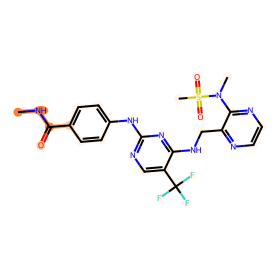

bbb_logbb
0.979


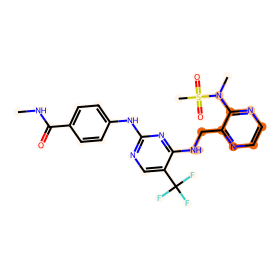

vd
0.9364


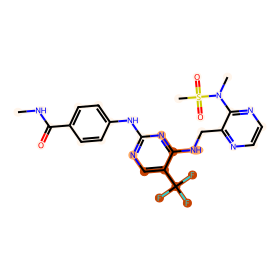

fu
0.7644


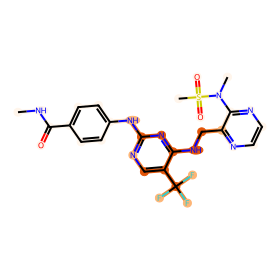

oatp1b3
0.7675


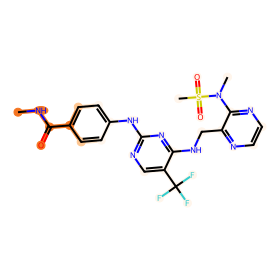

oatp1b1
0.817


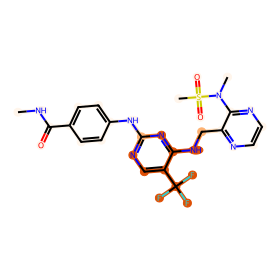

cyp3a4_inhibitor
0.4856


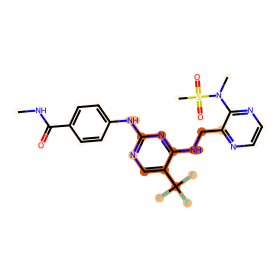

cyp2d6_inhibitor
0.0551


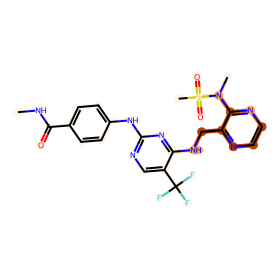

cyp2c9_inhibitor
0.14


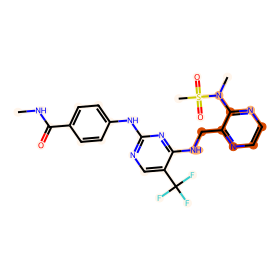

cyp2c19_inhibitor
0.0847


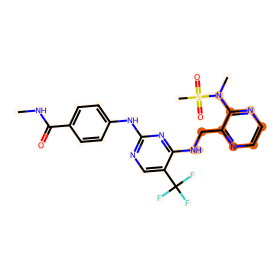

cyp1a2_inhibitor
0.5242


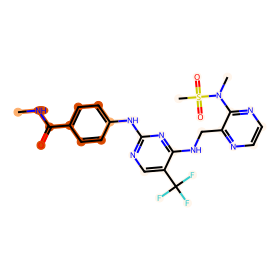

cyp3a4_substrate
0.7183


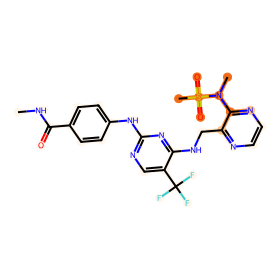

cyp2d6_substrate
0.1097


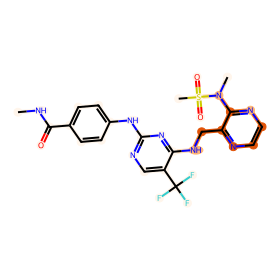

cyp2c9_substrate
0.7262


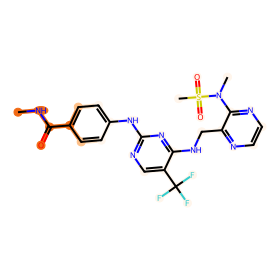

cyp2c19_substrate
0.0105


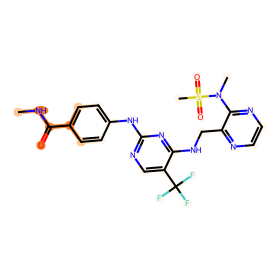

cyp1a2_substrate
0.1844


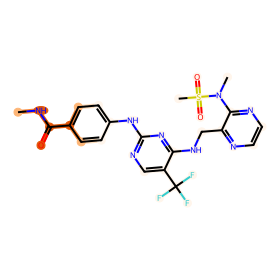

bcrp
0.7104


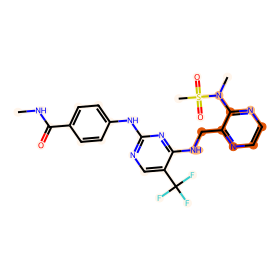

t0.5
0.1931


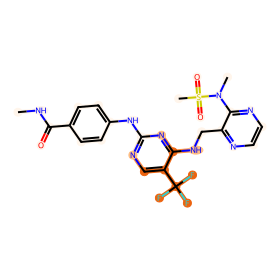

nr_ahr
0.6446


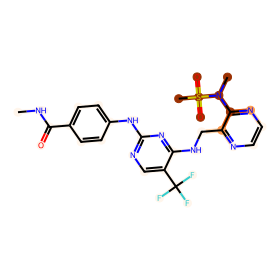

nr_ar
0.0995


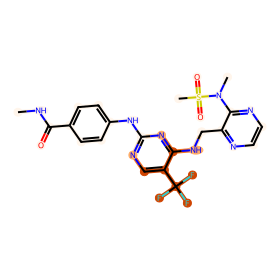

nr_ar_lbd
0.2949


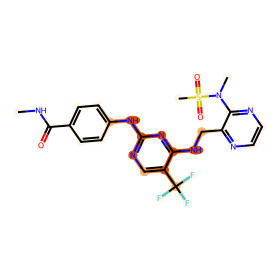

nr_er
0.6361


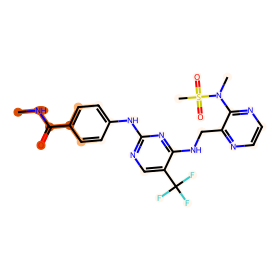

nr_er_lbd
0.0805


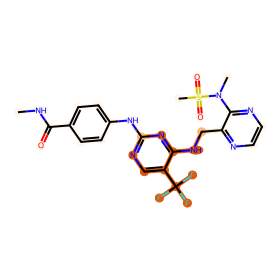

nr_tr
0.9425


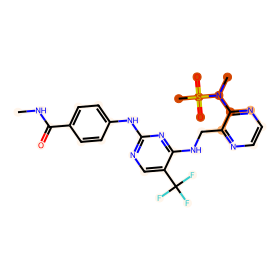

nr_gr
0.7645


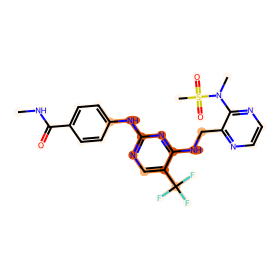

nr_ppar_gamma
0.8914


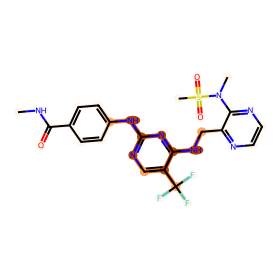

nr_aromatase
0.7473


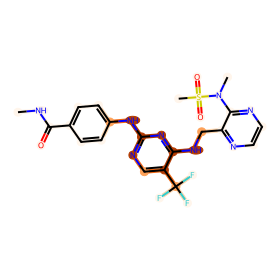

sr_are
0.8103


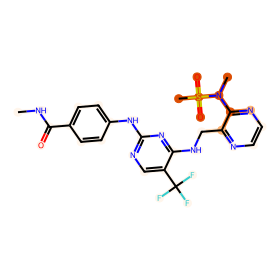

sr_atad5
0.9555


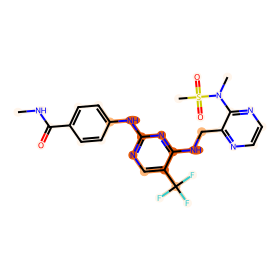

sr_hse
0.0867


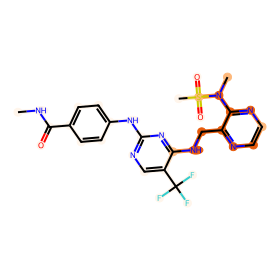

sr_mmp
0.4335


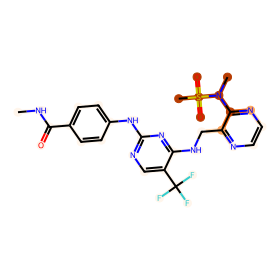

sr_p53
0.8653


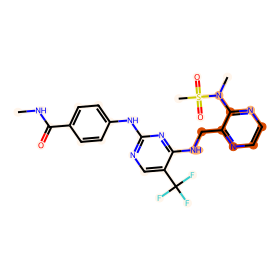

skin_sens
0.0221


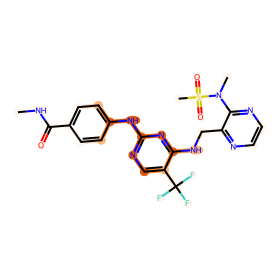

respiratory_tox
0.9401


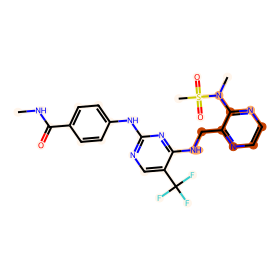

micronucleus_tox
0.9952


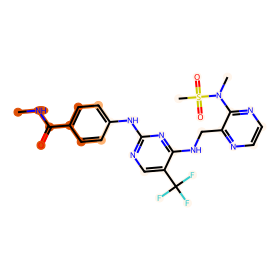

herg
0.6565


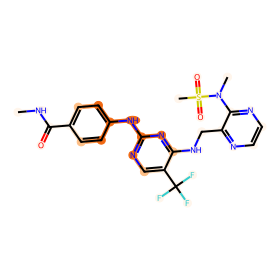

h_ht
0.9809


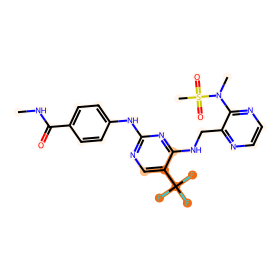

eye_irritation
0.0126


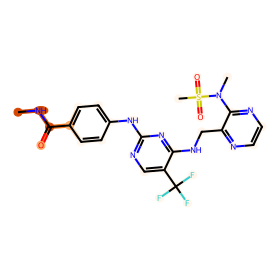

eye_corrosion
0.003


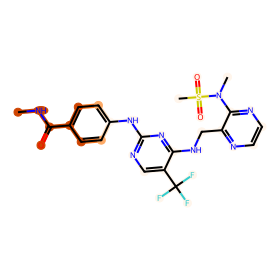

dili
0.6032


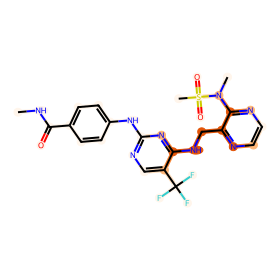

crustacean
0.0336


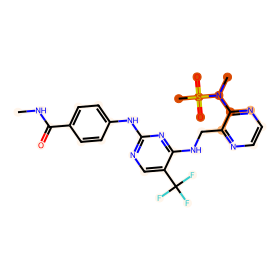

carcinogenicity
0.3602


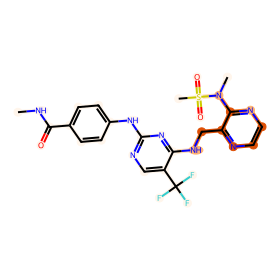

biodegradation
0.5213


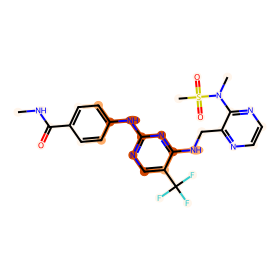

bee_tox
0.0108


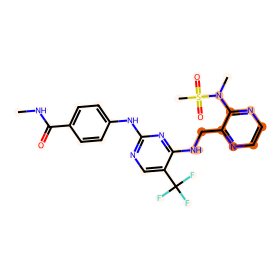

avian_tox
0.1185


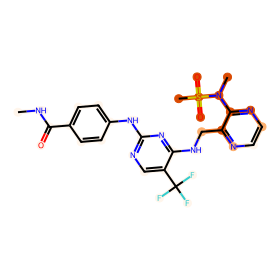

ames
0.355


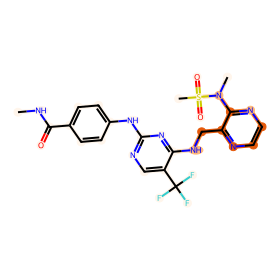

pka
8.1751


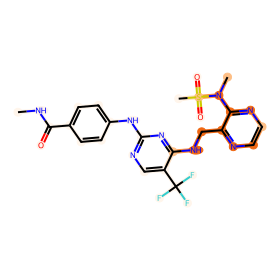

pkb
2.7262


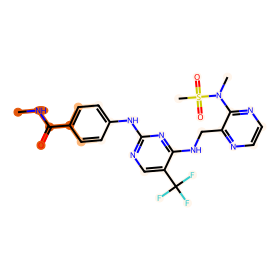

logd
2.3855


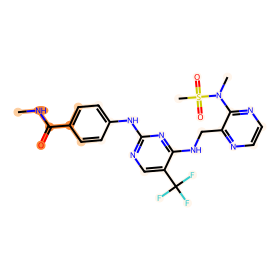

logp
1.4786


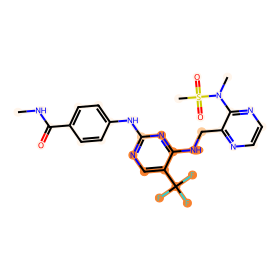

logs
-3.3744


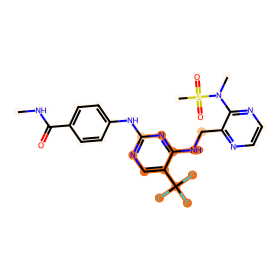

logvp
-1.581


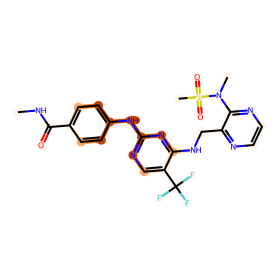

hydrationE
6.1555


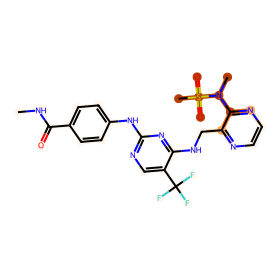

bp
-73.1723


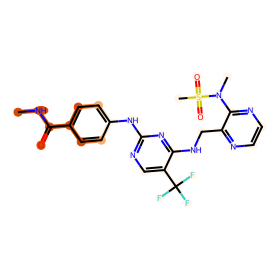

mp
147.0253


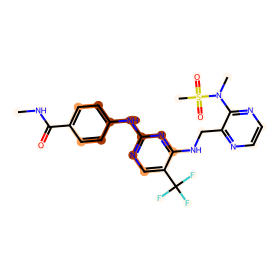

In [7]:
import json
import base64
from IPython.display import SVG, display

# JSON 파일 읽기
with open('/home/doyamoon/MGA-main/test/test.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# 각 항목의 sub_structure를 디코딩하여 SVG 이미지로 표시
for item in data:
    for prediction in item.get("Predict", []):
    
        # base64로 인코딩된 sub_structure 가져오기
        encoded_svg = prediction.get("sub_structure")
        if encoded_svg:
            # base64 디코딩
            decoded_svg = base64.b64decode(encoded_svg).decode('utf-8')
            
            # SVG 이미지를 Jupyter Notebook에 표시
            print(prediction.get("task"))
            print(prediction.get("value"))        
            display(SVG(decoded_svg))
